# About

This notebook shows code used to process experimental data for the paper.
The following code closely follows the code in `3_data_processing.ipynb`.
For more details, please refer to that notebook.

# Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tqdm
from pathlib import Path

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

from processing import ModelPB, ModelY, DataContainer

# Flag to control whether to skip the model optimization process and use pretrained models instead
USE_PRETRAINED_MODELS = True

First, we load the data and store it in `DataContainer` objects.
The experimental data are located in the `data/helmholtz_experiment` folder in NumPy’s `.npz` format.

In [2]:
_data_p_b = np.load(Path.cwd() / "data" / "helmholtz_experiment" / "p_b.npz")

p_b_data = DataContainer(
    p=_data_p_b["p"],
    z=_data_p_b["z"],
    freq=_data_p_b["freq"],
)

_data_p_t = np.load(Path.cwd() / "data" / "helmholtz_experiment" / "p_t.npz")

p_s_data = DataContainer(
    p=_data_p_t["p"] - p_b_data.p,
    z=_data_p_t["z"],
    freq=_data_p_t["freq"],
)

assert np.allclose(p_b_data.z, p_s_data.z)

# Raw data

First, we apply
$$
\sigma_\text{ext} = \frac{4\pi}{k}\operatorname{Im}\left[\frac{p_\text{s}(z)}{p_\text{b}(z)}\right]\frac{zR}{z+R}
$$
directly

/var/folders/gb/c4dxrb656yvf36d5mf8p1ggw0000gn/T/ipykernel_28238/3135673441.py:5: RuntimeWarning: invalid value encountered in divide
  sigma_ext = 4 * np.pi / k * np.imag(p_s_data.p / p_b_data.p) * z * R / (z + R)


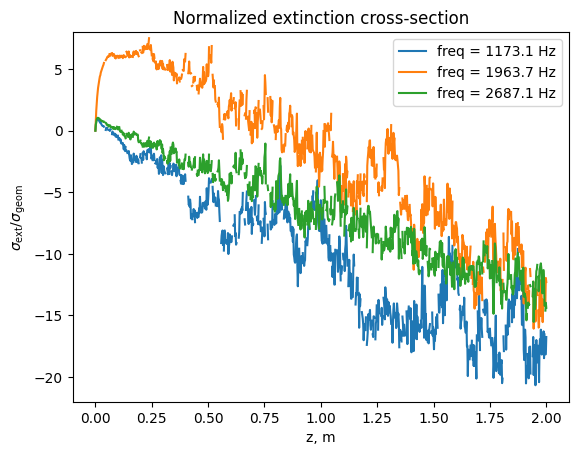

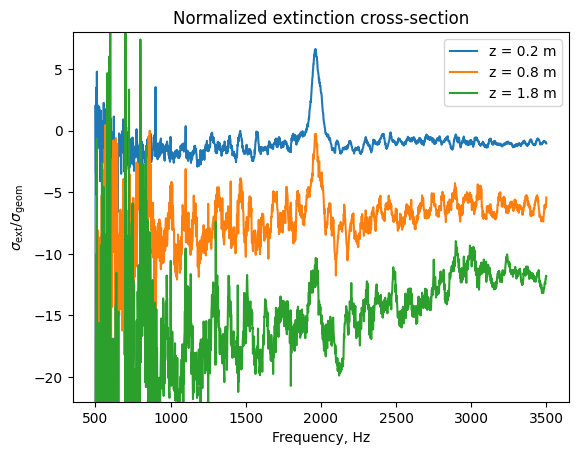

In [73]:
k = 2 * np.pi * p_b_data.freq / 343  # assuming speed of sound 343 m/s
R = 0.5  # assuming distance from the source to the scatterer is 0.5 m
z = p_b_data.z[..., None]

sigma_ext = 4 * np.pi / k * np.imag(p_s_data.p / p_b_data.p) * z * R / (z + R)
sigma_geom = np.pi * (0.01195) ** 2

for i in [400, 870, 1300]:
    plt.plot(z, sigma_ext[:, i] / sigma_geom, label=f"freq = {p_b_data.freq[i]:.1f} Hz")

plt.legend()
plt.xlabel("z, m")
plt.ylabel(r"$\sigma_\text{ext} / \sigma_\text{geom}$")
plt.title("Normalized extinction cross-section")
plt.ylim(-22, 8)
plt.show()


for i in [100, 400, 900]:
    plt.plot(
        p_b_data.freq, sigma_ext[i, :] / sigma_geom, label=f"z = {p_b_data.z[i]:.1f} m"
    )

plt.legend()
plt.xlabel("Frequency, Hz")
plt.ylabel(r"$\sigma_\text{ext} / \sigma_\text{geom}$")
plt.title("Normalized extinction cross-section")
plt.ylim(-22, 8)
plt.show()

# First Step

In [3]:
p_b_model = ModelPB(
    p0_prime_abs=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 1.0),
    ),
    p0_prime_phase=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 0.0),
    ),
    R_prime=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 5.0),
    ),
    R_prime_max=2.0,
    c=torch.nn.Parameter(torch.tensor(400.0)),
    L=torch.nn.Parameter(torch.tensor(1.0)),
    L_max=10.0,
    r_hat_abs=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, -3.0),
    ),
    r_hat_phase=torch.nn.Parameter(
        torch.full(p_b_data.freq.shape, 0.0),
    ),
)

print(p_b_model)  # Print the initialized model parameters

ModelPB()
Parameters:
  |p0_prime|: mean=1.313, min=1.313, max=1.313
     R_prime: mean=1.987, min=1.987, max=1.987
           c: 400.000
           L: 7.311
     |r_hat|: mean=0.049, min=0.049, max=0.049


In [4]:
freq_b_optim = torch.tensor(p_b_data.freq, dtype=torch.get_default_dtype())
_z_mask = ~np.isnan(p_b_data.p[:, 0])
p_b_optim = torch.tensor(p_b_data.p[_z_mask], dtype=torch.tensor(1 + 1j).dtype)
z_prime_b_optim = torch.tensor(p_b_data.z[_z_mask], dtype=torch.get_default_dtype())

In [5]:
if not USE_PRETRAINED_MODELS:
    torch.manual_seed(2001)

    dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(p_b_optim, z_prime_b_optim),
        batch_size=200,
        shuffle=True,
    )

    optimizer = torch.optim.Adam(
        p_b_model.parameters(),
        lr=0.1,
    )
    losses = []

    progress_bar = tqdm.tqdm(
        range(5000),
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar:20}{r_bar}",
    )

    for epoch in progress_bar:
        epoch_losses = []
        for batch in dataloader:
            diff = p_b_model(freq_b_optim, batch[1]) - batch[0]
            loss = torch.mean(diff.real**2 + diff.imag**2)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))
        progress_bar.set_postfix({"loss": f"{losses[-1]:.3e}"})

    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss in epoch")
    plt.title("Training Loss")
    plt.show()

    # torch.save(
    #     p_b_model.state_dict(),
    #     Path.cwd() / "data" / "helmholtz_experiment" / "models" / "p_b_model.pt",
    # )
else:
    p_b_model.load_state_dict(
        torch.load(
            Path.cwd() / "data" / "helmholtz_experiment" / "models" / "p_b_model.pt",
            weights_only=True,
        )
    )

In [6]:
print(p_b_model)

ModelPB()
Parameters:
  |p0_prime|: mean=179.529, min=21.863, max=321.108
     R_prime: mean=0.472, min=0.383, max=2.000
           c: 349.413
           L: 9.829
     |r_hat|: mean=0.010, min=0.003, max=0.029


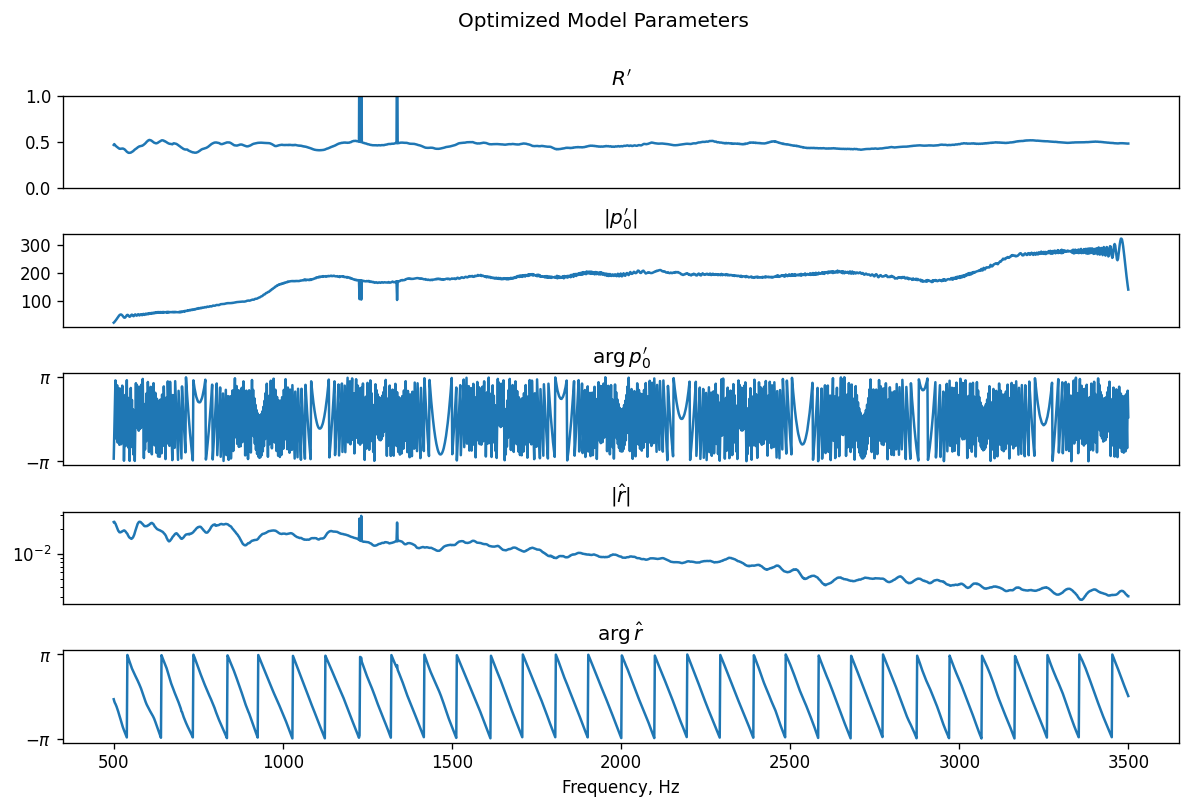

In [7]:
plt.figure(figsize=(12, 7), dpi=120)

plt.subplot(5, 1, 1)

freq = p_b_data.freq
plt.plot(freq, p_b_model.R_prime.numpy(force=True))
plt.title("$R'$")
plt.xticks([])
plt.ylim(0, 1)

plt.subplot(5, 1, 2)
plt.plot(freq, np.abs(p_b_model.p0_prime.numpy(force=True)))
plt.title("$|p_0'|$")
plt.xticks([])

plt.subplot(5, 1, 3)
plt.plot(freq, np.angle(p_b_model.p0_prime.numpy(force=True)))
plt.title("$\\arg p_0'$")
plt.yticks([-np.pi, np.pi], ["$-\\pi$", "$\\pi$"])
plt.xticks([])

plt.subplot(5, 1, 4)
plt.plot(freq, np.abs(p_b_model.r_hat.numpy(force=True)))
plt.title("$|\\hat{r}|$")
plt.xticks([])
plt.yscale("log")

plt.subplot(5, 1, 5)
plt.plot(freq, np.angle(p_b_model.r_hat.numpy(force=True)))
plt.title("$\\arg \\hat{r}$")
plt.yticks([-np.pi, np.pi], ["$-\\pi$", "$\\pi$"])
plt.xlabel("Frequency, Hz")

plt.suptitle("Optimized Model Parameters")
plt.subplots_adjust(hspace=0.5)
plt.show()

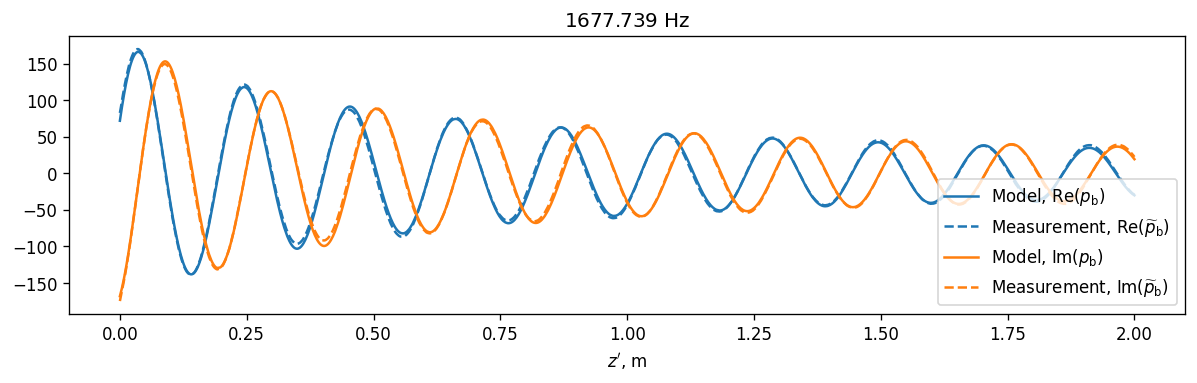

In [8]:
plt.figure(figsize=(12, 3), dpi=120)

i = 700
with torch.no_grad():
    freq = p_b_data.freq
    z_prime = z_prime_b_optim.numpy(force=True)

    _experiment = p_b_optim.numpy(force=True)
    _model = p_b_model(freq_b_optim, z_prime_b_optim).numpy(force=True)

    plt.plot(z_prime, np.real(_model[:, i]), label="Model, $\\text{Re}(p_\\text{b})$")
    plt.plot(
        z_prime,
        np.real(_experiment[:, i]),
        "--",
        color="tab:blue",
        label="Measurement, $\\text{Re}(\\widetilde{p}_\\text{b})$",
    )

    plt.plot(z_prime, np.imag(_model[:, i]), label="Model, $\\text{Im}(p_\\text{b})$")
    plt.plot(
        z_prime,
        np.imag(_experiment[:, i]),
        "--",
        color="tab:orange",
        label="Measurement, $\\text{Im}(\\widetilde{p}_\\text{b})$",
    )

    plt.title(f"${freq[i]:.3f}$ Hz")
    plt.xlabel("$z'$, m")
    plt.legend()
    plt.show()

# Second Step

In [9]:
p0_prime = p_b_model.p0_prime.numpy(force=True)[None, ...]
c = p_b_model.c.numpy(force=True)
k = 2 * np.pi * p_s_data.freq / c

y = np.imag(p_s_data.p / (p0_prime * np.exp(1j * k * p_s_data.z[..., None])))

In [10]:
y_model = ModelY(
    R_prime=p_b_model.R_prime.detach(),
    c=p_b_model.c.detach(),
    Delta=torch.nn.Parameter(torch.tensor(-2.0)),
    Delta_max=0.05,
    sigma=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, -5.0),
    ),
    A_im=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 0.0),
    ),
    C=torch.nn.Parameter(
        torch.full(p_s_data.freq.shape, 0.0),
    ),
)

print(y_model)  # Print the initialized model parameters

ModelY()
Parameters:
  Delta: 0.006
  sigma: mean=0.007, min=0.007, max=0.007
   A_im: mean=0.000, min=0.000, max=0.000
      C: mean=0.000, min=0.000, max=0.000


Here we apply an additional filter on $z'$.
In the experiment, the measurements started with the microphone positioned against the wall of the resonator.
Therefore, the measurements at small values of $z'$ should be excluded.

In [11]:
freq_y_optim = torch.tensor(p_s_data.freq, dtype=torch.get_default_dtype())
# remove NaNs and near-wall measurements (z' < 0.01)
_z_mask = (~np.isnan(y[:, 0])) & (p_s_data.z >= 0.01)
y_optim = torch.tensor(y[_z_mask], dtype=torch.get_default_dtype())
z_prime_y_optim = torch.tensor(p_s_data.z[_z_mask], dtype=torch.get_default_dtype())

In [12]:
if not USE_PRETRAINED_MODELS:
    torch.manual_seed(2001)

    dataloader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(y_optim, z_prime_y_optim),
        batch_size=350,
        shuffle=True,
    )

    optimizer = torch.optim.Adam(
        y_model.parameters(),
        lr=0.01,
    )
    losses = []

    progress_bar = tqdm.tqdm(
        range(8000),
        dynamic_ncols=True,
        leave=True,
        bar_format="{l_bar}{bar:20}{r_bar}",
    )

    for epoch in progress_bar:

        epoch_losses = []
        for batch in dataloader:

            loss = torch.mean(
                torch.abs(y_model(freq_y_optim, batch[1]) - batch[0]) ** 2
            )
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))
        progress_bar.set_postfix({"loss": f"{losses[-1]:.3e}"})

    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Average loss in epoch")
    plt.title("Training Loss")
    plt.show()

    # torch.save(
    #     y_model.state_dict(),
    #     Path.cwd() / "data" / "helmholtz_experiment" / "models" / "y_model.pt",
    # )
else:
    y_model.load_state_dict(
        torch.load(
            Path.cwd() / "data" / "helmholtz_experiment" / "models" / "y_model.pt",
            weights_only=True,
        )
    )

In [13]:
print(y_model)  # Print the optimized model parameters

ModelY()
Parameters:
  Delta: 0.013
  sigma: mean=0.000, min=0.000, max=0.004
   A_im: mean=0.136, min=-0.057, max=0.518
      C: mean=-0.009, min=-0.014, max=-0.001


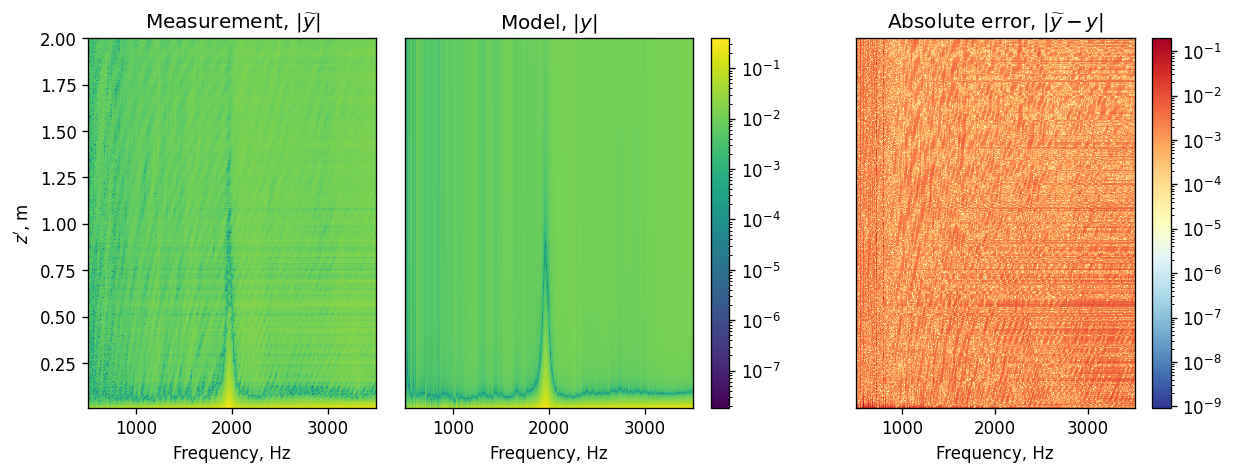

In [14]:
plt.figure(figsize=(12, 4), dpi=120)

freq = p_s_data.freq
z_prime = z_prime_y_optim.numpy(force=True)

_experiment = y_optim.numpy(force=True)
_model = y_model(freq_y_optim, z_prime_y_optim).numpy(force=True)
_error = np.abs(_experiment - _model)

vmax = max(np.max(np.abs(_experiment)), np.max(np.abs(_model)))
vmin = min(np.min(np.abs(_experiment)), np.min(np.abs(_model)))

plt.subplot(1, 3, 1)
plt.pcolormesh(
    freq, z_prime, np.abs(_experiment), vmin=vmin, vmax=vmax, cmap="viridis", norm="log"
)
plt.title("Measurement, $|\\widetilde{y}|$")
plt.ylabel("$z'$, m")
plt.xlabel("Frequency, Hz")

plt.subplot(1, 3, 2)
cm = plt.pcolormesh(
    freq, z_prime, np.abs(_model), vmin=vmin, vmax=vmax, cmap="viridis", norm="log"
)
plt.title("Model, $|y|$")
plt.yticks([])
plt.xlabel("Frequency, Hz")

plt.subplots_adjust(wspace=0.1)
plt.gcf().colorbar(cm, ax=plt.gcf().axes[:], pad=0.025)

plt.subplot(1, 3, 3)
plt.pcolormesh(freq, z_prime, _error, cmap="RdYlBu_r", norm="log")
plt.title("Absolute error, $|\\widetilde{y} - y|$")
plt.yticks([])
plt.xlabel("Frequency, Hz")
plt.colorbar()

plt.show()

Now we compare the obtained extinction cross-section with the results from COMSOL simulations.
These results were generated using a COMSOL model that can be built and executed via Python.
Example scripts are provided in the `comsol` folder, including `data/helmholtz_pw_comsol/script.py`, which was used to generate this particular dataset.

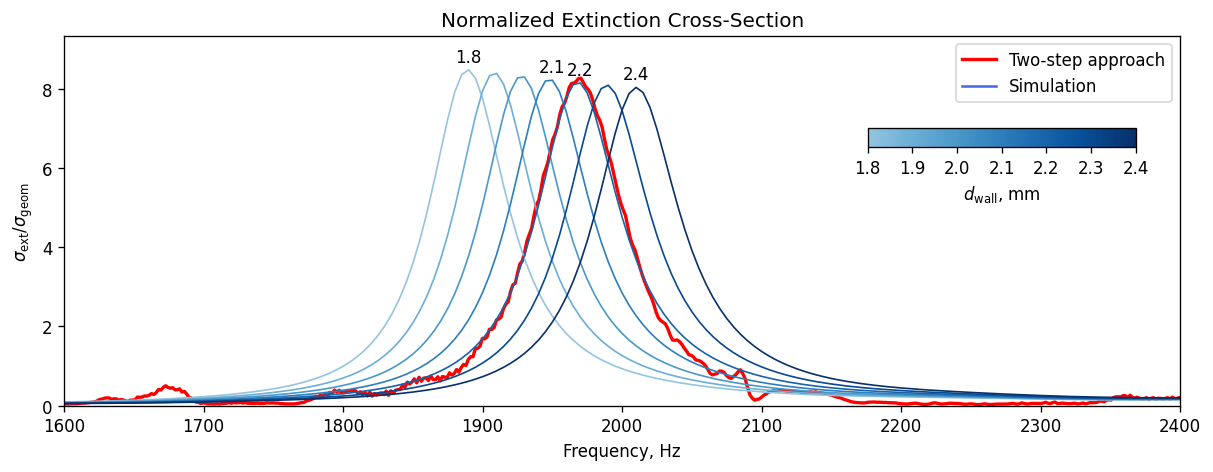

In [15]:
plt.figure(figsize=(12, 4), dpi=120)

freq = p_s_data.freq
sigma_geom = np.pi * (0.01195) ** 2

# Two-step approach result
plt.plot(
    freq,
    y_model.sigma.numpy(force=True) / sigma_geom,
    label="Two-step approach",
    color="red",
    linewidth=2,
)

# COMSOL results
df = pd.read_csv(Path.cwd() / "data" / "helmholtz_pw_comsol" / "sigma.csv")

cmap = LinearSegmentedColormap.from_list(
    "mycmap", plt.get_cmap("Blues")(np.linspace(0.4, 1, 100))
)
norm = Normalize(min(df["d_wall_p"]), max(df["d_wall_p"]))

for d_wall_p in df["d_wall_p"].unique():
    plt.plot(
        df[df["d_wall_p"] == d_wall_p]["freq"],
        df[df["d_wall_p"] == d_wall_p]["sigma_ext"] / sigma_geom,
        "-",
        color=cmap(norm(d_wall_p)),
        linewidth=1,
    )

    if round(d_wall_p, 1) in [1.8, 2.1, 2.2, 2.4]:
        i = np.argmax(df[df["d_wall_p"] == d_wall_p]["sigma_ext"])
        plt.text(
            df[df["d_wall_p"] == d_wall_p]["freq"].iloc[i],
            (df[df["d_wall_p"] == d_wall_p]["sigma_ext"] / sigma_geom).iloc[i] + 0.2,
            round(d_wall_p, 1),
            horizontalalignment="center",
        )

# Add colorbar
new_axes = plt.gca().inset_axes((0.72, 0.7, 0.24, 0.05), transform=plt.gca().transAxes)
sm = ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, new_axes, orientation="horizontal")
new_axes.set_xticks(df["d_wall_p"].unique())
new_axes.set_xlabel("$d_\\text{wall}$, mm")

# Legend
new_line = Line2D([], [], color="royalblue", label="Simulation")
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(new_line)
labels.append("Simulation")
plt.legend(handles, labels)


plt.xlim(1600, 2400)
plt.xlabel("Frequency, Hz")
plt.ylabel("$\\sigma_\\text{ext} / \\sigma_\\text{geom}$")
plt.title("Normalized Extinction Cross-Section")
plt.ylim(0)
plt.show()

In the experiment, the Helmholtz resonator was 3D-printed with $d_\text{wall}=2.1$ mm.
To explain the shift in the resonant frequency, we also include curves for different $d_\text{wall}$ values.
This comparison shows that small geometric imperfections can account for the observed difference.